**ROZDZIAŁ 1: Instalacja i Importy**

In [142]:
!pip install kagglehub
import kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import kagglehub
import shutil
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


**ROZDZIAŁ 2: Pobieranie i Przygotowanie Danych**


In [143]:
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")

breed_map = {
    '01': 'Akhal-Teke', '02': 'Appaloosa', '03': 'Orlov Trotter',
    '04': 'Vladimir Heavy Draft', '05': 'Percheron',
    '06': 'Arabian', '07': 'Friesian'
}

image_data = []
for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            label = file.split('_')[0]
            image_data.append({'path': full_path, 'label': label})

full_df = pd.DataFrame(image_data)
full_df['label'] = full_df['label'].astype(str)

train_df, temp_df = train_test_split(
    full_df, test_size=0.3, random_state=42, stratify=full_df['label']
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f"Dane załadowane. Trening: {len(train_df)}, Walidacja: {len(valid_df)}, Test: {len(test_df)}")


Using Colab cache for faster access to the 'horse-breeds' dataset.
Dane załadowane. Trening: 469, Walidacja: 100, Test: 101


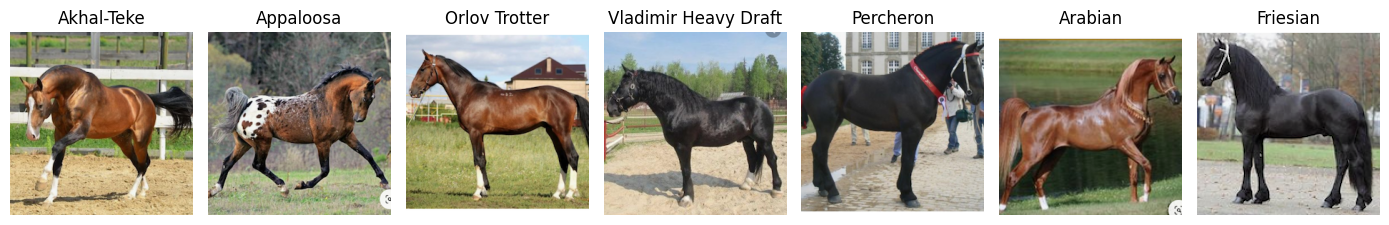

In [144]:

# wizualizacja ras
CLASS_NAMES = sorted(full_df['label'].unique())
CLASS_MAPPING = breed_map
all_files = full_df['path'].tolist()
num_classes = len(CLASS_NAMES)

def show_one_per_class():

    plt.figure(figsize=(14,4))

    for i,cls in enumerate(CLASS_NAMES):

        for f in all_files:
            if os.path.basename(f).startswith(cls):

                img = Image.open(f)

                plt.subplot(1,num_classes,i+1)
                plt.imshow(img)
                plt.title(CLASS_MAPPING[cls])
                plt.axis("off")

                break

    plt.tight_layout()
    plt.show()

show_one_per_class()


**ROZDZIAŁ 3: Augmentacja i Generatory**

In [145]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

#genrator
train = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val = val_datagen.flow_from_dataframe(
    valid_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

Found 469 validated image filenames belonging to 7 classes.
Found 100 validated image filenames belonging to 7 classes.
Found 101 validated image filenames belonging to 7 classes.


**ROZDZIAŁ 4: Budowa Modelu**

In [146]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    #BatchNormalization()  no significant gain in validation metrics.,
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    #BatchNormalization() no significant gain in validation metrics.,
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    Conv2D(128, (3,3), activation='relu'),
    #BatchNormalization(),
    MaxPooling2D(),

   # Conv2D(256, (3,3), activation='relu'),
    #MaxPooling2D() no significant gain in validation metrics.,

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [147]:
early_stop = EarlyStopping(
    monitor='val_loss',     # patrzy na walidację
    patience=5,             # ile epok czeka
    restore_best_weights=True
)

In [148]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**ROZDZIAŁ 5. Trening**

In [149]:
history = model.fit(
    train,
    validation_data=val,
    epochs=30,
     ##callbacks=[early_stop]
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 811ms/step - accuracy: 0.1748 - loss: 2.1098 - val_accuracy: 0.1500 - val_loss: 1.8922
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2026 - loss: 1.8873 - val_accuracy: 0.1800 - val_loss: 1.8793
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 543ms/step - accuracy: 0.2281 - loss: 1.8521 - val_accuracy: 0.2800 - val_loss: 1.7928
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 624ms/step - accuracy: 0.3241 - loss: 1.7217 - val_accuracy: 0.2300 - val_loss: 1.7243
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 985ms/step - accuracy: 0.3667 - loss: 1.6582 - val_accuracy: 0.3200 - val_loss: 1.6738
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 685ms/step - accuracy: 0.3859 - loss: 1.6136 - val_accuracy: 0.3700 - val_loss: 1.6247
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 613ms/step - accuracy: 0.3795 - loss: 1.5675 - val_accuracy: 0.3700 - val_loss: 1.5680
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 545ms/step - accuracy: 0.4371 - loss: 1.5314 - val_accuracy: 0

** ROZDZIAŁ 6. Wizualizacja Wyników **

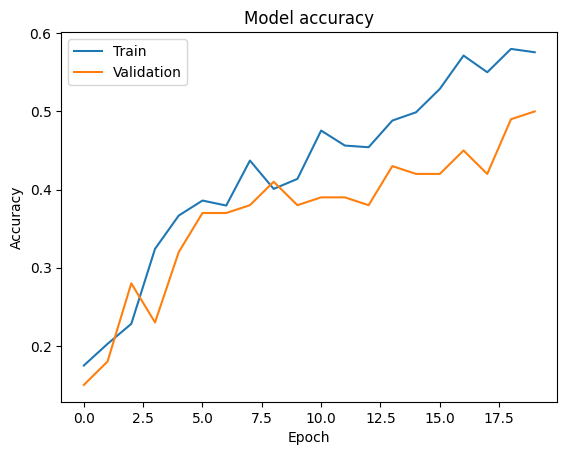

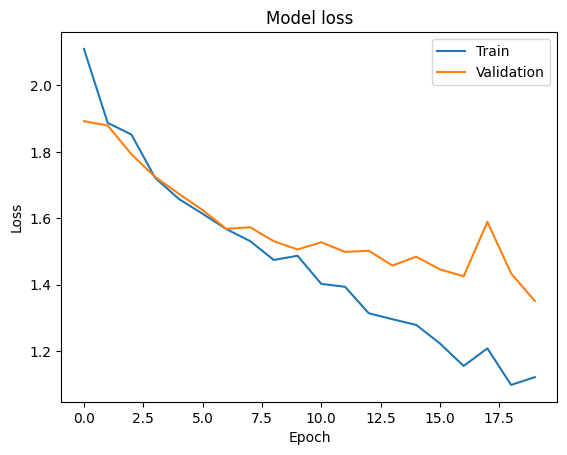

Found 101 validated image filenames belonging to 7 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step

Classification Report:
                      precision    recall  f1-score   support

          Akhal-Teke       0.38      0.47      0.42        19
           Appaloosa       0.52      0.75      0.62        16
       Orlov Trotter       0.50      0.31      0.38        16
Vladimir Heavy Draft       1.00      0.20      0.33         5
           Percheron       0.33      0.12      0.18         8
             Arabian       0.33      0.21      0.26        19
            Friesian       0.64      1.00      0.78        18

            accuracy                           0.50       101
           macro avg       0.53      0.44      0.42       101
        weighted avg       0.49      0.50      0.46       101



In [150]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

# accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Prepare test generator
# Reusing the existing datagen, but for test_df.
# The validation_split parameter is ignored when subset is not used.
test_gen = datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Important to maintain order for true labels
)

# Get true labels
y_true = test_gen.classes

# Get predictions
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)

# Get class names in the order used by the generator
class_indices = test_gen.class_indices
idx_to_label = dict((v, k) for k, v in class_indices.items())
class_names = [breed_map[idx_to_label[i]] for i in range(len(idx_to_label))]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

**ROZDZIAŁ 7: Test Wizualny**

In [152]:
#wizualizacja predykcji

def show_predictions_by_class(model):

    plt.figure(figsize=(14,4))

    for i,cls in enumerate(CLASS_NAMES):

        img_path = None

        for f in all_files:
            if os.path.basename(f).startswith(cls):
                img_path = f
                break

        if img_path is None:
            continue

        img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)

        # You would need a predict_image function defined elsewhere if you want to use it
        # For now, let's just show the true label
        true_name = CLASS_MAPPING[cls]

        # This part requires a predict_image function, which is not defined in the provided notebook structure.
        # For demonstration, we'll just show the true label.
        # pred_id, pred_name = predict_image(model, img_path)
        # plt.title(f"GT: {true_name}\nPred: {pred_name}")

        plt.subplot(1, num_classes, i+1)
        plt.imshow(img)
        plt.title(f"GT: {true_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Predykcje Sequential


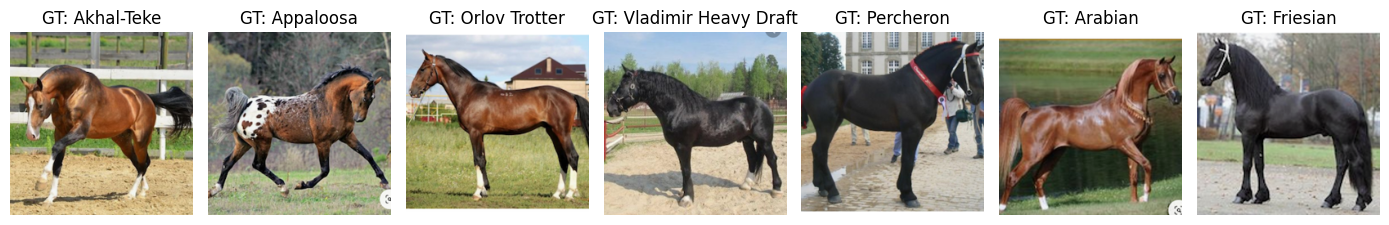

In [153]:
print("Predykcje Sequential")
show_predictions_by_class(model)

PRZYKŁADOWE PREDYKCJE NA ZBIORZE TESTOWYM:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


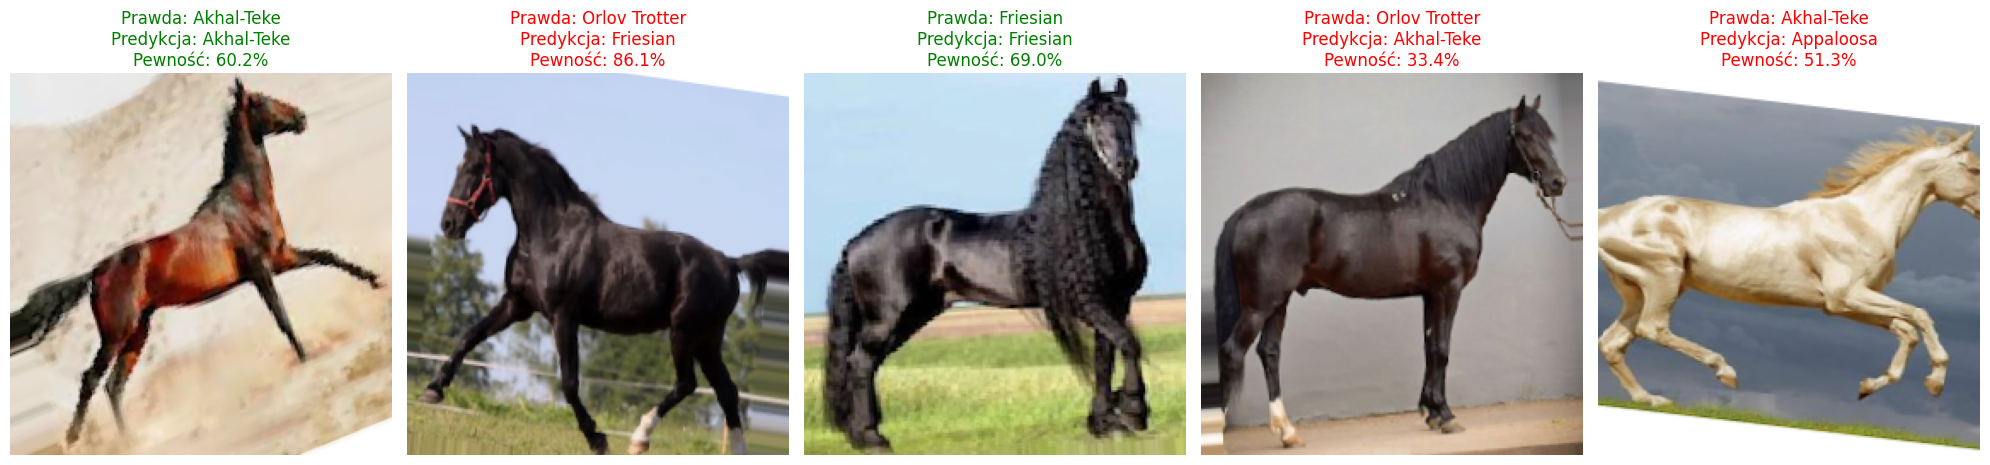

PRZYKŁADOWE PREDYKCJE NA ZBIORZE Validacyjnym:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


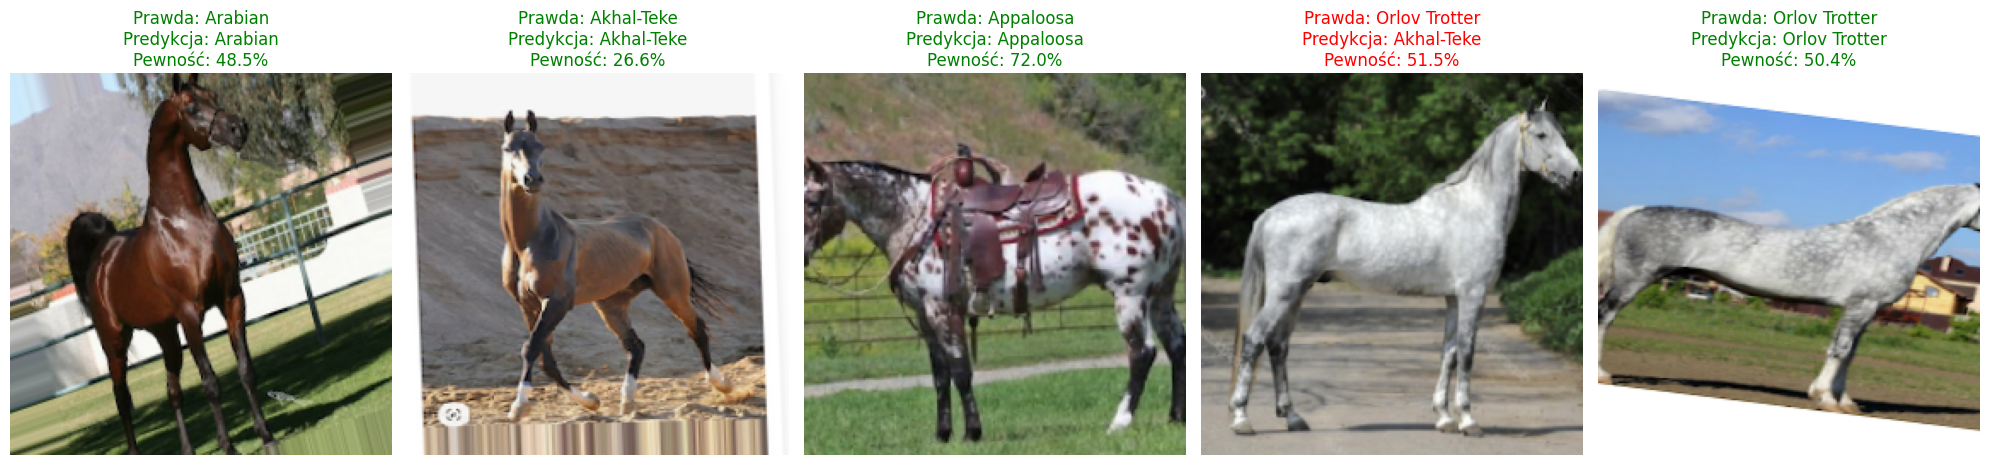

In [154]:
def visualize_predictions(model, test_gen, breed_map, n=5):

    images, labels = next(test_gen)
    predictions = model.predict(images)

    plt.figure(figsize=(20, 10))


    indices = random.sample(range(len(images)), n)

    for i, idx in enumerate(indices):
        img = images[idx]
        true_label_idx = np.argmax(labels[idx]) # Fixed line: Use np.argmax for one-hot encoded labels
        pred_label_idx = np.argmax(predictions[idx])
        confidence = np.max(predictions[idx]) * 100


        class_indices_rev = {v: k for k, v in test_gen.class_indices.items()}
        true_code = class_indices_rev[true_label_idx]
        pred_code = class_indices_rev[pred_label_idx]

        true_name = breed_map.get(true_code, "Unknown")
        pred_name = breed_map.get(pred_code, "Unknown")

        color = 'green' if true_label_idx == pred_label_idx else 'red'

        plt.subplot(1, n, i + 1)
        display_img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(display_img)
        plt.title(f"Prawda: {true_name}\nPredykcja: {pred_name}\nPewność: {confidence:.1f}%", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("PRZYKŁADOWE PREDYKCJE NA ZBIORZE TESTOWYM:")
visualize_predictions(model, test_gen, breed_map)
print("PRZYKŁADOWE PREDYKCJE NA ZBIORZE Validacyjnym:")
visualize_predictions(model, test_gen, breed_map)

